
# SOB4ES - Comparación de Modelos

### CRISP-ML(Q) - Fase 5: Evaluación y selección del modelo final

Este notebook carga los modelos entrenados en los notebooks anteriores y compara su rendimiento sobre `eval.csv` de forma sistemática.

**Modelos comparados:**
1. Random Forest individual (modelos por target)
2. XGBoost individual (modelos por target)
3. Ridge Regression individual (modelos por target)
4. Random Forest multisalida
5. XGBoost multisalida
6. Ensemble de RegressorChains
7. MLP multisalida estándar
8. MLP con pérdida personalizada de correlación

**Métricas de comparación:**
- R2 global (promedio sobre todos los targets)
- R2 por target (para identificar grupos biológicos difíciles de predecir)
- RMSE y MAE globales

## 1.- Configuración

Configuración inicial del entorno, con librerías, variables globales y todo cargado.

In [1]:
import os
import warnings
import joblib
import pandas as pd
import numpy as np
import itertools

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')

DATA_DIR  = 'input/'
MODELS_BASE = 'output/models/'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]

FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    #'cu_z',
    'k_z',
    #'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

print('Configuracion cargada.')

# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

Configuracion cargada.


## 2.- Carga de eval.csv

Se carga únicamente el dataset de evaluación final. Ninguno de los modelos ha visto estos datos durante el entrenamiento ni el tuning.

In [2]:
df_eval = pd.read_csv(os.path.join(DATA_DIR, 'eval.csv'))
X_eval  = df_eval[FEATURES_AUTORIZADAS]
y_eval  = df_eval[TARGETS]

print(f'eval.csv cargado: {X_eval.shape[0]} muestras x {X_eval.shape[1]} variables')


eval.csv cargado: 65 muestras x 32 variables


## 3.- Funciones auxiliares

Se definen las funciones necesarias para cargar cada tipo de modelo y calcular sus predicciones sobre `eval.csv`.

In [3]:
def metricas(y_true, y_pred, nombre):
    """Calcula R2, RMSE y MAE globales y devuelve un dict con los resultados."""
    r2   = r2_score(y_true, y_pred, multioutput='uniform_average')
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='uniform_average'))
    mae  = mean_absolute_error(y_true, y_pred, multioutput='uniform_average')
    r2_targets = r2_score(y_true, y_pred, multioutput='raw_values')
    return {'modelo': nombre, 'R2': round(r2, 4), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'r2_targets': r2_targets}


def predecir_ensamble_pkl(carpeta, prefijo, sufijo, n, X):
    """Carga n modelos .pkl y devuelve el promedio de sus predicciones."""
    preds = []
    for i in range(n):
        m = joblib.load(os.path.join(MODELS_BASE, carpeta, f'{prefijo}{i}{sufijo}.pkl'))
        preds.append(m.predict(X))
    return np.mean(preds, axis=0)


def predecir_ensamble_por_target(carpeta, prefijo_tpl, n, X):
    """
    Para modelos individuales (un modelo por target):
    carga n modelos por target y devuelve la matriz de predicciones.
    prefijo_tpl debe ser una funcion que recibe (target, seed_id) y devuelve el nombre del archivo.
    """
    y_pred = np.zeros((len(X), len(TARGETS)))
    for j, target in enumerate(TARGETS):
        preds_t = []
        for i in range(n):
            ruta = os.path.join(MODELS_BASE, carpeta, prefijo_tpl(target, i))
            m    = joblib.load(ruta)
            preds_t.append(m.predict(X))
        y_pred[:, j] = np.mean(preds_t, axis=0)
    return y_pred


class MLPMultiSalida(nn.Module):
    def __init__(self, n_inputs, n_outputs, hidden_sizes, dropout_rate):
        super().__init__()
        layers, in_size = [], n_inputs
        for h in hidden_sizes:
            layers += [nn.Linear(in_size, h), nn.ReLU(), nn.Dropout(dropout_rate)]
            in_size = h
        layers.append(nn.Linear(in_size, n_outputs))
        self.red = nn.Sequential(*layers)
    def forward(self, x): return self.red(x)


def predecir_ensamble_mlp(carpeta, prefijo, n, X, config_file):
    """Carga n redes PyTorch y devuelve el promedio de sus predicciones."""
    cfg   = joblib.load(os.path.join(MODELS_BASE, carpeta, config_file))
    X_t   = torch.tensor(X.values, dtype=torch.float32).to(DEVICE)
    preds = []
    for i in range(n):
        model = MLPMultiSalida(X.shape[1], len(TARGETS), cfg['hidden'], cfg['dropout']).to(DEVICE)
        model.load_state_dict(torch.load(
            os.path.join(MODELS_BASE, carpeta, f'{prefijo}{i}.pt'), map_location=DEVICE
        ))
        model.eval()
        with torch.no_grad():
            preds.append(model(X_t).cpu().numpy())
    return np.mean(preds, axis=0)


print('Funciones auxiliares definidas.')


Funciones auxiliares definidas.


## 4.- Predicciones de cada modelo

Se cargan y ejecutan todos los modelos sobre `eval.csv`. Este proceso puede tardar varios minutos dependiendo del número de modelos y el hardware disponible.

In [4]:
resultados = []
y_true = y_eval.values

print('Cargando modelos y generando predicciones...\n')

# 1. Random Forest individual
print('  [1/8] Random Forest individual...')
y_pred = predecir_ensamble_por_target('rf', lambda t, i: f'rf_prod_{t}_m{i}.pkl', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'RF Individual'))

# 2. XGBoost individual
print('  [2/8] XGBoost individual...')
y_pred = predecir_ensamble_por_target('xgb', lambda t, i: f'xgb_prod_{t}_exp{i}.pkl', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'XGBoost Individual'))

# 3. Ridge individual
print('  [3/8] Ridge Regression...')
y_pred_ridge = np.zeros((len(X_eval), len(TARGETS)))
for j, target in enumerate(TARGETS):
    m = joblib.load(os.path.join(MODELS_BASE, 'reg', f'ridge_prod_{target}.pkl'))
    y_pred_ridge[:, j] = m.predict(X_eval)
resultados.append(metricas(y_true, y_pred_ridge, 'Regresión Individual'))

# 4. RF multisalida
print('  [4/8] Random Forest multisalida...')
y_pred = predecir_ensamble_pkl('rf_multi', 'rf_multi_m', '', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'RandomForest Multisalida'))

# 5. XGBoost multisalida
print('  [5/8] XGBoost multisalida...')
y_pred = predecir_ensamble_pkl('xgb_multi', 'xgb_multi_exp', '', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'XGBoost Multisalida'))

# 6. RegressorChain
print('  [6/8] Ensemble RegressorChain...')
N_CHAINS   = 10
preds_chain = []
for chain_id in range(N_CHAINS):
    cadena = joblib.load(os.path.join(MODELS_BASE, 'chain', f'chain_{chain_id}.pkl'))
    preds_chain.append(cadena.predict(X_eval))
y_pred = np.mean(preds_chain, axis=0)
resultados.append(metricas(y_true, y_pred, 'Random Forest con RegressorChain'))

# 7. MLP estandar
print('  [7/8] MLP multisalida estandar...')
y_pred = predecir_ensamble_mlp('mlp', 'mlp_prod_', 5, X_eval, 'mlp_config.pkl')
resultados.append(metricas(y_true, y_pred, 'MLP Estandar'))

# 8. MLP con perdida personalizada
print('  [8/8] MLP perdida personalizada...')
y_pred = predecir_ensamble_mlp('mlp_custom', 'mlp_custom_', 5, X_eval, 'mlp_custom_config.pkl')
resultados.append(metricas(y_true, y_pred, 'MLP Perdida Custom'))

print('\nPredicciones completadas...')


Cargando modelos y generando predicciones...

  [1/8] Random Forest individual...


  [2/8] XGBoost individual...


  [3/8] Ridge Regression...
  [4/8] Random Forest multisalida...


  [5/8] XGBoost multisalida...


  [6/8] Ensemble RegressorChain...


  [7/8] MLP multisalida estandar...
  [8/8] MLP perdida personalizada...

Predicciones completadas...


## 5.- Tabla comparativa global

Se muestra la comparación ordenada por R2 descendente. 

El mejor modelo es el que tiene R2 más alto y RMSE/MAE más bajos.

Comparacion de modelos (ordenado por R2 descendente):
                             Modelo  R2 global    RMSE     MAE
1          RandomForest Multisalida     0.0985  0.9185  0.7013
2                     RF Individual     0.0875  0.9185  0.6939
3               XGBoost Multisalida     0.0807  0.9182  0.6819
4  Random Forest con RegressorChain     0.0799  0.9167  0.6797
5                XGBoost Individual     0.0676  0.9293  0.7049
6                      MLP Estandar     0.0471  0.9352  0.6946
7              Regresión Individual    -0.0267  0.9687  0.7443
8                MLP Perdida Custom    -0.0807  0.9675  0.7103

Mejor modelo: RandomForest Multisalida (R2 = 0.0985)


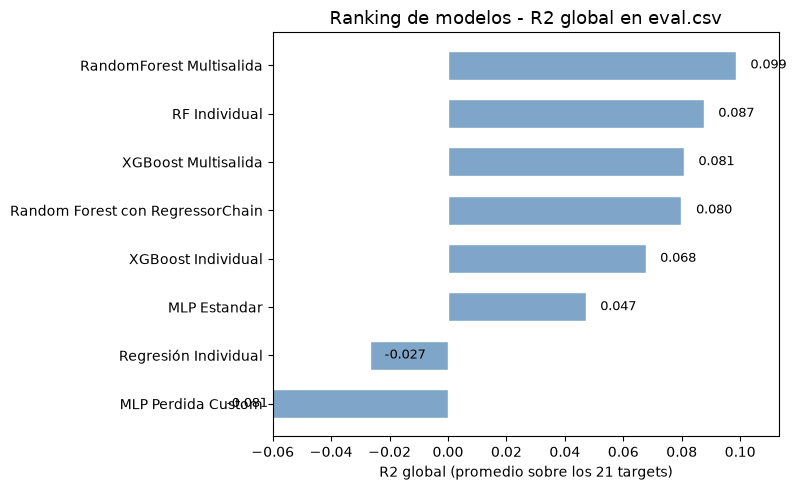

In [5]:
tabla = pd.DataFrame([{
    'Modelo': r['modelo'],
    'R2 global': r['R2'],
    'RMSE':      r['RMSE'],
    'MAE':       r['MAE']
} for r in resultados]).sort_values('R2 global', ascending=False).reset_index(drop=True)

tabla.index += 1  # ranking desde 1
print('Comparacion de modelos (ordenado por R2 descendente):')
print('=' * 60)
print(tabla.to_string())
print('=' * 60)
print(f'\nMejor modelo: {tabla.iloc[0]["Modelo"]} (R2 = {tabla.iloc[0]["R2 global"]})')

# Grafico: ranking de modelos por R2 global
fig, ax = plt.subplots(figsize=(8, 5))
_orden = tabla.sort_values('R2 global')
ax.barh(_orden['Modelo'], _orden['R2 global'], color=PALETTE['blue'], edgecolor='white', height=0.6)
for i, v in enumerate(_orden['R2 global']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('R2 global (promedio sobre los 21 targets)')
ax.set_title('Ranking de modelos - R2 global en eval.csv', fontsize=13)
ax.set_xlim(-0.060, _orden['R2 global'].max() * 1.15)
plt.tight_layout()
plt.show()

## 6.- Comparación por target

Se muestra el R2 de cada modelo para cada grupo biológico. 

Esto permite identificar para que grupos funciona mejor cada enfoque y si hay grupos que ninguno de los modelos predice bien (posiblemente por falta de datos o por relaciones muy ruidosas con las variables predictoras).

R2 por target y modelo:
Modelo                   RandomForest Multisalida  RF Individual  XGBoost Multisalida  Random Forest con RegressorChain  XGBoost Individual  MLP Estandar  Regresión Individual  MLP Perdida Custom
Target                                                                                                                                                                                             
GLOBAL                                     0.0985         0.0875               0.0807                            0.0799              0.0676        0.0471               -0.0267             -0.0807
nematode_shannon_z                         0.1645         0.1366               0.2339                            0.1551              0.1600        0.1238                0.0022              0.0846
macro_shannon_z                            0.2026         0.3158               0.3958                            0.2913              0.2578        0.2491                0.1254              0.2

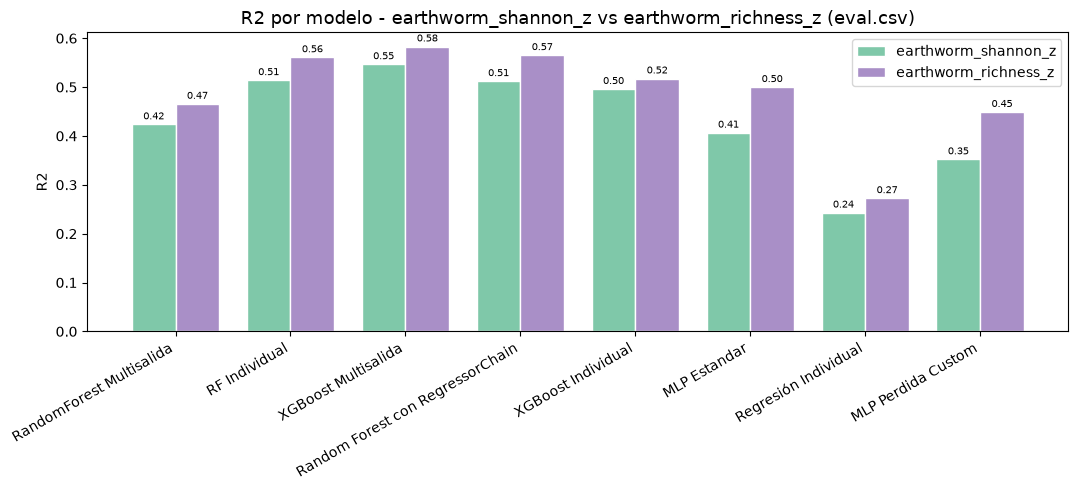

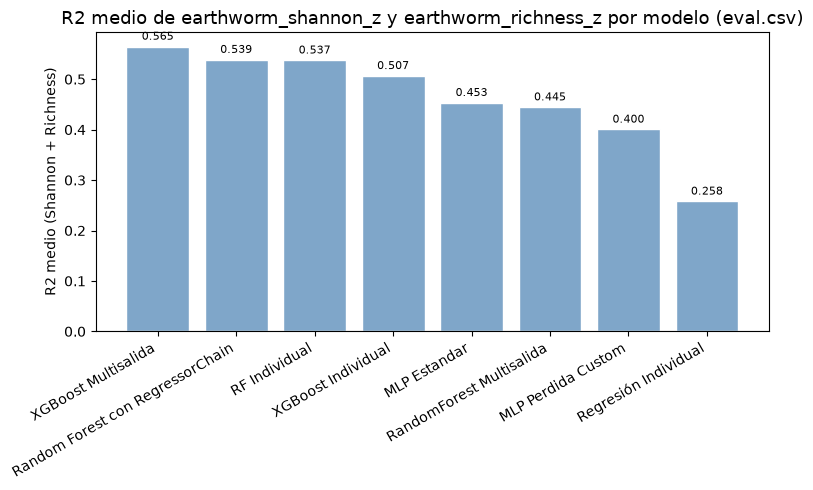

In [6]:
# Construimos una tabla con R2 por target para cada modelo
filas = []
for r in resultados:
    fila = {'Target': 'GLOBAL', 'Modelo': r['modelo'], 'R2': r['R2']}
    filas.append(fila)
    for t, r2_t in zip(TARGETS, r['r2_targets']):
        filas.append({'Target': t, 'Modelo': r['modelo'], 'R2': round(float(r2_t), 4)})

df_r2 = pd.DataFrame(filas).pivot(index='Target', columns='Modelo', values='R2')

# Ordenamos los targets: GLOBAL primero, luego por R2 medio descendente
orden = ['GLOBAL'] + [t for t in TARGETS]
df_r2 = df_r2.loc[orden]

# Ordenamos las columnas por R2 global descendente
orden_modelos = tabla['Modelo'].tolist()
df_r2 = df_r2[orden_modelos]

print('R2 por target y modelo:')
print('=' * 120)
print(df_r2.to_string())
print('=' * 120)
print('\nTargets con R2 medio < 0.2 en todos los modelos (posiblemente difíciles de predecir):')
media_por_target = df_r2.drop('GLOBAL').mean(axis=1)
dificiles = media_por_target[media_por_target < 0.2]
if len(dificiles) > 0:
    for t, v in dificiles.items():
        print(f'  {t:30} R2 medio: {v:.4f}')
else:
    print('  Ninguno.')

# Grafico: R2 por modelo para los targets principales (Shannon y Richness de lombrices)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]  # colores fijos del proyecto: shannon / richness

_df_main = df_r2.loc[_targets_plot]
_x = np.arange(len(orden_modelos))
_width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
for i, (tgt, col) in enumerate(zip(_targets_plot, _colors_plot)):
    offset = (i - 0.5) * _width
    bars = ax.bar(_x + offset, _df_main.loc[tgt, orden_modelos], _width,
                   label=tgt, color=col, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

ax.set_xticks(_x)
ax.set_xticklabels(orden_modelos, rotation=30, ha='right')
ax.set_ylabel('R2')
ax.set_title('R2 por modelo - earthworm_shannon_z vs earthworm_richness_z (eval.csv)', fontsize=13)
ax.axhline(0, color=PALETTE['gray'], linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

# Grafico: R2 medio (Shannon + Richness) por modelo
_media_principal = _df_main.loc[_targets_plot, orden_modelos].mean(axis=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(_media_principal.index, _media_principal.values, color=PALETTE['blue'], edgecolor='white')
ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=3)
ax.set_xticklabels(_media_principal.index, rotation=30, ha='right')
ax.set_ylabel('R2 medio (Shannon + Richness)')
ax.set_title('R2 medio de earthworm_shannon_z y earthworm_richness_z por modelo (eval.csv)', fontsize=13)
ax.axhline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

# 7.- Exportación de las comparaciones de regresión

In [7]:
os.makedirs('output/regresion', exist_ok=True)

# Guardamos la tabla comparativa para referencia futura
tabla.to_csv('output/regresion/comparacion_modelos.csv', index=False)
df_r2.to_csv('output/regresion/r2_por_target.csv')

print('Resultados guardados en output/regresion/comparacion_modelos.csv y output/regresion/r2_por_target.csv')


Resultados guardados en output/regresion/comparacion_modelos.csv y output/regresion/r2_por_target.csv


# 8.- Prueba de clasificación

En este notebook también se realiza una pequeña prueba de clasificación para comprobar si los rankings cambian cuando se hace las pruebas tenienod en cuenta los resultados de regresión o no.

Iniciando Análisis Avanzado con Métricas de Clasificación Blanda...
[INFO] Cargado train.csv con éxito. Umbrales calculados sobre train + eval.

Generando predicciones para los 8 modelos...
  [1/8] Recalculando RF Individual...


  [2/8] Recalculando XGBoost Individual...


  [3/8] Recalculando Regresión Individual (Ridge)...
  [4/8] Recalculando RandomForest Multisalida...


  [5/8] Recalculando XGBoost Multisalida...


  [6/8] Recalculando Random Forest con RegressorChain...


  [7/8] Recalculando MLP Estandar...
  [8/8] Recalculando MLP Perdida Custom...
¡Predicciones obtenidas con éxito!


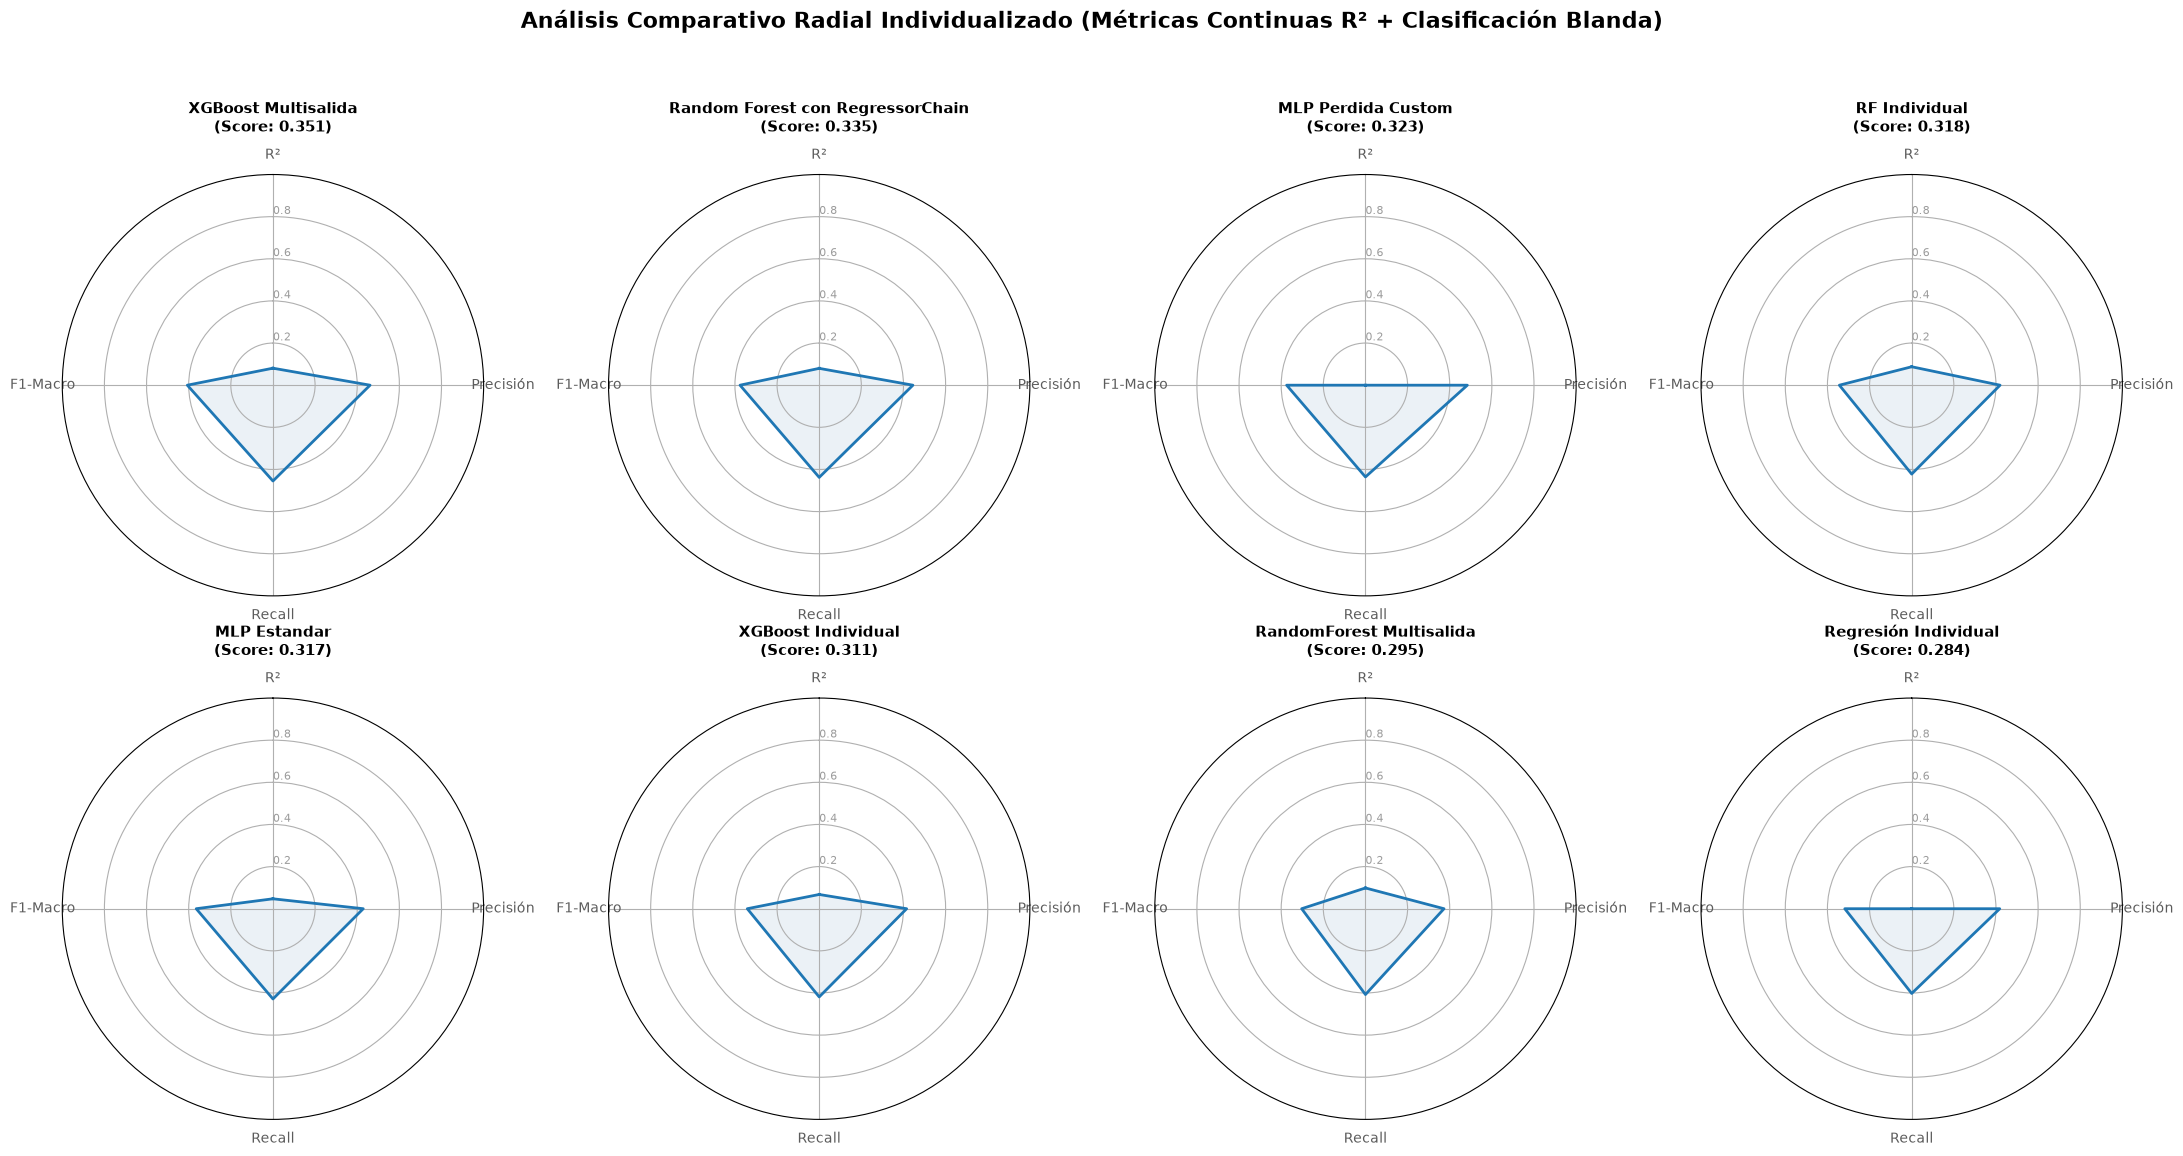

  Top 8 modelos (Métricas de Regresión Original + Clasificación Blanda)  
Top 1: XGBoost Multisalida                 | Compuesto: 0.3507 | R2:  0.0807 | P: 0.4609 | R: 0.4548 | F1: 0.4065
Top 2: Random Forest con RegressorChain    | Compuesto: 0.3345 | R2:  0.0799 | P: 0.4448 | R: 0.4376 | F1: 0.3758
Top 3: MLP Perdida Custom                  | Compuesto: 0.3234 | R2: -0.0807 | P: 0.4837 | R: 0.4356 | F1: 0.3741
Top 4: RF Individual                       | Compuesto: 0.3181 | R2:  0.0875 | P: 0.4194 | R: 0.4220 | F1: 0.3434
Top 5: MLP Estandar                        | Compuesto: 0.3171 | R2:  0.0471 | P: 0.4286 | R: 0.4284 | F1: 0.3643
Top 6: XGBoost Individual                  | Compuesto: 0.3107 | R2:  0.0676 | P: 0.4151 | R: 0.4187 | F1: 0.3413
Top 7: RandomForest Multisalida            | Compuesto: 0.2954 | R2:  0.0985 | P: 0.3728 | R: 0.4074 | F1: 0.3027
Top 8: Regresión Individual                | Compuesto: 0.2844 | R2: -0.0267 | P: 0.4179 | R: 0.4022 | F1: 0.3176


In [8]:
# Paso 1: Carga de datos y preparación segura de percentiles
print("Iniciando Análisis Avanzado con Métricas de Clasificación Blanda...")
try:
    # Intentamos cargar train.csv usando la ruta configurada en el notebook
    df_train_tmp = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
    df_combinado = pd.concat([df_train_tmp[TARGETS], df_eval[TARGETS]], axis=0)
    print("[INFO] Cargado train.csv con éxito. Umbrales calculados sobre train + eval.")
except Exception as e:
    df_combinado = df_eval[TARGETS]
    print("[WARN] No se pudo cargar train.csv, usando solo eval.csv para umbrales:", e)

os.makedirs('output/regresion/graphs', exist_ok=True)

y_true = y_eval.values

# Paso 2: Recalcular predicciones de todos los modelos de forma explícita y segura
dicc_preds = {}
print("\nGenerando predicciones para los 8 modelos...")

# 1. Random Forest individual
print("  [1/8] Recalculando RF Individual...")
dicc_preds['RF Individual'] = predecir_ensamble_por_target('rf', lambda t, i: f'rf_prod_{t}_m{i}.pkl', 5, X_eval)

# 2. XGBoost individual
print("  [2/8] Recalculando XGBoost Individual...")
dicc_preds['XGBoost Individual'] = predecir_ensamble_por_target('xgb', lambda t, i: f'xgb_prod_{t}_exp{i}.pkl', 5, X_eval)

# 3. Ridge individual
print("  [3/8] Recalculando Regresión Individual (Ridge)...")
y_pred_ridge = np.zeros((len(X_eval), len(TARGETS)))
for j, target in enumerate(TARGETS):
    m = joblib.load(os.path.join(MODELS_BASE, 'reg', f'ridge_prod_{target}.pkl'))
    y_pred_ridge[:, j] = m.predict(X_eval)
dicc_preds['Regresión Individual'] = y_pred_ridge

# 4. RF multisalida
print("  [4/8] Recalculando RandomForest Multisalida...")
dicc_preds['RandomForest Multisalida'] = predecir_ensamble_pkl('rf_multi', 'rf_multi_m', '', 5, X_eval)

# 5. XGBoost multisalida
print("  [5/8] Recalculando XGBoost Multisalida...")
dicc_preds['XGBoost Multisalida'] = predecir_ensamble_pkl('xgb_multi', 'xgb_multi_exp', '', 5, X_eval)

# 6. RegressorChain
print("  [6/8] Recalculando Random Forest con RegressorChain...")
N_CHAINS = 10
preds_chain = []
for chain_id in range(N_CHAINS):
    cadena = joblib.load(os.path.join(MODELS_BASE, 'chain', f'chain_{chain_id}.pkl'))
    preds_chain.append(cadena.predict(X_eval))
dicc_preds['Random Forest con RegressorChain'] = np.mean(preds_chain, axis=0)

# 7. MLP estandar
print("  [7/8] Recalculando MLP Estandar...")
dicc_preds['MLP Estandar'] = predecir_ensamble_mlp('mlp', 'mlp_prod_', 5, X_eval, 'mlp_config.pkl')

# 8. MLP con perdida personalizada
print("  [8/8] Recalculando MLP Perdida Custom...")
dicc_preds['MLP Perdida Custom'] = predecir_ensamble_mlp('mlp_custom', 'mlp_custom_', 5, X_eval, 'mlp_custom_config.pkl')

print("¡Predicciones obtenidas con éxito!")

# Paso 3: Calcular métricas combinadas (Regresión R² + Clasificación)
filas_radar = []

for nombre_modelo, y_pred in dicc_preds.items():
    # Extraer el R2 global calculado previamente en la Celda 4 de resultados
    r2_global = 0.0
    for res in resultados:
        if res['modelo'] == nombre_modelo:
            r2_global = res['R2']
            break
            
    # Calcular métricas de clasificación blanda por target discretizando en Bajo/Medio/Alto
    precisions, recalls, f1s = [], [], []
    for j, target in enumerate(TARGETS):
        valores_ref = df_combinado[target].dropna().values
        p33 = np.percentile(valores_ref, 33)
        p66 = np.percentile(valores_ref, 66)
        
        t_disc = np.zeros_like(y_true[:, j], dtype=int)
        t_disc[y_true[:, j] > p33] = 1
        t_disc[y_true[:, j] > p66] = 2
        
        p_disc = np.zeros_like(y_pred[:, j], dtype=int)
        p_disc[y_pred[:, j] > p33] = 1
        p_disc[y_pred[:, j] > p66] = 2
        
        precisions.append(precision_score(t_disc, p_disc, average='macro', zero_division=0))
        recalls.append(recall_score(t_disc, p_disc, average='macro', zero_division=0))
        f1s.append(f1_score(t_disc, p_disc, average='macro', zero_division=0))
        
    precision_m = np.mean(precisions)
    recall_m = np.mean(recalls)
    f1_m = np.mean(f1s)
    
    # Puntuación compuesta balanceada (R2 acotado a 0 si es muy bajo/negativo para visualización uniforme)
    r2_clipped = max(0, r2_global)
    score_compuesto = (r2_clipped + precision_m + recall_m + f1_m) / 4
    
    filas_radar.append({
        'Modelo': nombre_modelo,
        'R2': r2_global,
        'Precision': precision_m,
        'Recall': recall_m,
        'F1_Macro': f1_m,
        'Score_Compuesto': score_compuesto
    })

df_radar_orig = pd.DataFrame(filas_radar).sort_values(by='Score_Compuesto', ascending=False)

# Paso 4: Generación del Mosaico de Gráficos de Radar
categorias = ['R²', 'Precisión', 'Recall', 'F1-Macro']
N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, axes = plt.subplots(2, 4, figsize=(22, 11), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

os.makedirs('output', exist_ok=True)

for idx, (index, fila) in enumerate(df_radar_orig.iterrows()):
    ax = axes[idx]
    
    # Valores mapeados (R2 acotado a 0 para mantener escala proporcional positiva de 0 a 1)
    valores = [max(0, fila['R2']), fila['Precision'], fila['Recall'], fila['F1_Macro']]
    valores += valores[:1]
    
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    plt.sca(ax)
    plt.xticks(angulos[:-1], categorias, color=PALETTE['gray_dark'], size=10)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2","0.4","0.6","0.8"], color=PALETTE['gray'], size=8)
    plt.ylim(0, 1)
    
    # Dibujar polígono en el mosaico
    ax.plot(angulos, valores, linewidth=2, linestyle='solid')
    ax.fill(angulos, valores, color=PALETTE['blue'], alpha=0.15)
    ax.set_title(f"{fila['Modelo']}\n(Score: {fila['Score_Compuesto']:.3f})", fontsize=11, fontweight='bold', pad=12)
    
    # Guardar gráfico radial individual
    fig_ind, ax_ind = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='polar'))
    ax_ind.set_theta_offset(np.pi / 2)
    ax_ind.set_theta_direction(-1)
    ax_ind.plot(angulos, valores, linewidth=2, linestyle='solid', color=PALETTE['green'])
    ax_ind.fill(angulos, valores, color=PALETTE['green'], alpha=0.15)
    ax_ind.set_title(f"Análisis Radial: {fila['Modelo']}\nScore Compuesto: {fila['Score_Compuesto']:.4f}", fontsize=12, fontweight='bold', pad=15)
    ax_ind.set_xticklabels(categorias)
    ax_ind.set_ylim(0, 1)
    
    nombre_archivo = f"output/regresion/graphs/radar_regresion_{fila['Modelo'].lower().replace(' ', '_')}.png"
    fig_ind.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.close(fig_ind)

# Formatear mosaico general y guardar
fig.suptitle("Análisis Comparativo Radial Individualizado (Métricas Continuas R² + Clasificación Blanda)", fontsize=16, fontweight='bold', y=1.04)
fig.tight_layout()
fig.savefig('output/regresion/graphs/mosaico_radar_regresion.png', dpi=300, bbox_inches='tight')
plt.show()

# Paso 5: Imprimir el Ranking Top 8 Final

print("  Top 8 modelos (Métricas de Regresión Original + Clasificación Blanda)  ")

for i, (idx, fila) in enumerate(df_radar_orig.iterrows(), 1):
    print(f"Top {i}: {fila['Modelo']:<35} | Compuesto: {fila['Score_Compuesto']:.4f} | R2: {fila['R2']:>7.4f} | P: {fila['Precision']:.4f} | R: {fila['Recall']:.4f} | F1: {fila['F1_Macro']:.4f}")


In [9]:
# Paso 6: Metricas de clasificacion blanda (R2, Precision, Recall, F1) POR TARGET para cada modelo
print("Calculando metricas por target para el analisis por target...")

# Mapeo fijo modelo -> color, para que cada modelo tenga siempre el mismo color
# en todos los radares por target (facilita comparar visualmente entre targets)
modelos_lista = list(dicc_preds.keys())
color_por_modelo = {m: c for m, c in zip(modelos_lista, palette_cycle(len(modelos_lista)))}

filas_radar_target = []
for nombre_modelo, y_pred in dicc_preds.items():
    r2_por_target = r2_score(y_true, y_pred, multioutput='raw_values')

    for j, target in enumerate(TARGETS):
        valores_ref = df_combinado[target].dropna().values
        p33 = np.percentile(valores_ref, 33)
        p66 = np.percentile(valores_ref, 66)

        t_disc = np.zeros_like(y_true[:, j], dtype=int)
        t_disc[y_true[:, j] > p33] = 1
        t_disc[y_true[:, j] > p66] = 2

        p_disc = np.zeros_like(y_pred[:, j], dtype=int)
        p_disc[y_pred[:, j] > p33] = 1
        p_disc[y_pred[:, j] > p66] = 2

        precision_t = precision_score(t_disc, p_disc, average='macro', zero_division=0)
        recall_t    = recall_score(t_disc, p_disc, average='macro', zero_division=0)
        f1_t        = f1_score(t_disc, p_disc, average='macro', zero_division=0)
        r2_t        = float(r2_por_target[j])
        score_t     = (max(0, r2_t) + precision_t + recall_t + f1_t) / 4

        filas_radar_target.append({
            'Target': target,
            'Modelo': nombre_modelo,
            'R2': r2_t,
            'Precision': precision_t,
            'Recall': recall_t,
            'F1_Macro': f1_t,
            'Score_Compuesto': score_t
        })

df_radar_target = pd.DataFrame(filas_radar_target)
print(f"Metricas por target calculadas para {df_radar_target['Modelo'].nunique()} modelos "
      f"x {df_radar_target['Target'].nunique()} targets...")

Calculando metricas por target para el analisis por target...


Metricas por target calculadas para 8 modelos x 21 targets...


  Top 8 modelos por target (R2 + Clasificación)  



nematode_shannon_z:
  Top 1: XGBoost Multisalida                 | Compuesto: 0.4036 | R2:  0.2339 | P: 0.5077 | R: 0.4717 | F1: 0.4012
  Top 2: MLP Perdida Custom                  | Compuesto: 0.3439 | R2:  0.0846 | P: 0.5923 | R: 0.3883 | F1: 0.3102
  Top 3: XGBoost Individual                  | Compuesto: 0.2803 | R2:  0.1600 | P: 0.2736 | R: 0.3899 | F1: 0.2978
  Top 4: RandomForest Multisalida            | Compuesto: 0.2767 | R2:  0.1645 | P: 0.2791 | R: 0.3855 | F1: 0.2776
  Top 5: Regresión Individual                | Compuesto: 0.2692 | R2:  0.0022 | P: 0.4122 | R: 0.3615 | F1: 0.3008
  Top 6: Random Forest con RegressorChain    | Compuesto: 0.2681 | R2:  0.1551 | P: 0.2647 | R: 0.3732 | F1: 0.2796
  Top 7: RF Individual                       | Compuesto: 0.2566 | R2:  0.1366 | P: 0.2508 | R: 0.3710 | F1: 0.2678
  Top 8: MLP Estandar                        | Compuesto: 0.2370 | R2:  0.1238 | P: 0.2440 | R: 0.3399 | F1: 0.2402



macro_shannon_z:
  Top 1: XGBoost Multisalida                 | Compuesto: 0.5438 | R2:  0.3958 | P: 0.6472 | R: 0.5663 | F1: 0.5659
  Top 2: Random Forest con RegressorChain    | Compuesto: 0.4859 | R2:  0.2913 | P: 0.6777 | R: 0.4946 | F1: 0.4801
  Top 3: RF Individual                       | Compuesto: 0.4602 | R2:  0.3158 | P: 0.6346 | R: 0.4636 | F1: 0.4266
  Top 4: MLP Estandar                        | Compuesto: 0.4372 | R2:  0.2491 | P: 0.5547 | R: 0.4879 | F1: 0.4570
  Top 5: MLP Perdida Custom                  | Compuesto: 0.4337 | R2:  0.2562 | P: 0.5292 | R: 0.4879 | F1: 0.4613
  Top 6: XGBoost Individual                  | Compuesto: 0.4220 | R2:  0.2578 | P: 0.5667 | R: 0.4491 | F1: 0.4147
  Top 7: RandomForest Multisalida            | Compuesto: 0.3488 | R2:  0.2026 | P: 0.4633 | R: 0.4133 | F1: 0.3160
  Top 8: Regresión Individual                | Compuesto: 0.2831 | R2:  0.1254 | P: 0.3370 | R: 0.3855 | F1: 0.2843



earthworm_shannon_z:
  Top 1: XGBoost Multisalida                 | Compuesto: 0.7052 | R2:  0.5466 | P: 0.7703 | R: 0.7578 | F1: 0.7462
  Top 2: Random Forest con RegressorChain    | Compuesto: 0.6966 | R2:  0.5120 | P: 0.7703 | R: 0.7578 | F1: 0.7462
  Top 3: RF Individual                       | Compuesto: 0.6853 | R2:  0.5140 | P: 0.7564 | R: 0.7427 | F1: 0.7280
  Top 4: XGBoost Individual                  | Compuesto: 0.6432 | R2:  0.4958 | P: 0.7051 | R: 0.6925 | F1: 0.6794
  Top 5: RandomForest Multisalida            | Compuesto: 0.5823 | R2:  0.4235 | P: 0.6897 | R: 0.6366 | F1: 0.5793
  Top 6: MLP Estandar                        | Compuesto: 0.5525 | R2:  0.4065 | P: 0.6343 | R: 0.5944 | F1: 0.5748
  Top 7: MLP Perdida Custom                  | Compuesto: 0.5308 | R2:  0.3519 | P: 0.6023 | R: 0.5944 | F1: 0.5746
  Top 8: Regresión Individual                | Compuesto: 0.3810 | R2:  0.2429 | P: 0.4054 | R: 0.4720 | F1: 0.4035



orib_shannon_z:
  Top 1: MLP Perdida Custom                  | Compuesto: 0.3361 | R2:  0.2602 | P: 0.3918 | R: 0.4359 | F1: 0.2564
  Top 2: MLP Estandar                        | Compuesto: 0.3309 | R2:  0.2701 | P: 0.3908 | R: 0.4231 | F1: 0.2395
  Top 3: RF Individual                       | Compuesto: 0.2949 | R2:  0.1905 | P: 0.3889 | R: 0.3974 | F1: 0.2028
  Top 4: XGBoost Multisalida                 | Compuesto: 0.2948 | R2:  0.2397 | P: 0.2904 | R: 0.3949 | F1: 0.2541
  Top 5: RandomForest Multisalida            | Compuesto: 0.2908 | R2:  0.1740 | P: 0.3889 | R: 0.3974 | F1: 0.2028
  Top 6: Random Forest con RegressorChain    | Compuesto: 0.2550 | R2:  0.2380 | P: 0.2362 | R: 0.3359 | F1: 0.2098
  Top 7: Regresión Individual                | Compuesto: 0.1977 | R2:  0.1007 | P: 0.2444 | R: 0.3051 | F1: 0.1407
  Top 8: XGBoost Individual                  | Compuesto: 0.1933 | R2:  0.1518 | P: 0.1898 | R: 0.2846 | F1: 0.1469


...


bac_asv_richness_z:
  Top 1: XGBoost Multisalida                 | Compuesto: 0.3557 | R2:  0.0286 | P: 0.4949 | R: 0.4516 | F1: 0.4478
  Top 2: Regresión Individual                | Compuesto: 0.3470 | R2: -0.0853 | P: 0.5003 | R: 0.4573 | F1: 0.4305
  Top 3: MLP Estandar                        | Compuesto: 0.3448 | R2: -0.0904 | P: 0.4984 | R: 0.4503 | F1: 0.4305
  Top 4: MLP Perdida Custom                  | Compuesto: 0.3447 | R2: -0.1780 | P: 0.4944 | R: 0.4538 | F1: 0.4306
  Top 5: XGBoost Individual                  | Compuesto: 0.3302 | R2:  0.0000 | P: 0.4889 | R: 0.4364 | F1: 0.3956
  Top 6: RF Individual                       | Compuesto: 0.3257 | R2:  0.0180 | P: 0.4841 | R: 0.4205 | F1: 0.3800
  Top 7: RandomForest Multisalida            | Compuesto: 0.3099 | R2:  0.0131 | P: 0.5637 | R: 0.3786 | F1: 0.2842
  Top 8: Random Forest con RegressorChain    | Compuesto: 0.2898 | R2: -0.0280 | P: 0.4554 | R: 0.3652 | F1: 0.3385



fun_asv_richness_z:
  Top 1: MLP Estandar                        | Compuesto: 0.3864 | R2:  0.0202 | P: 0.6252 | R: 0.4578 | F1: 0.4425
  Top 2: MLP Perdida Custom                  | Compuesto: 0.3805 | R2:  0.0157 | P: 0.6724 | R: 0.4400 | F1: 0.3939
  Top 3: Regresión Individual                | Compuesto: 0.2913 | R2:  0.0084 | P: 0.4946 | R: 0.3733 | F1: 0.2888
  Top 4: Random Forest con RegressorChain    | Compuesto: 0.2911 | R2: -0.0240 | P: 0.4375 | R: 0.3844 | F1: 0.3426
  Top 5: XGBoost Multisalida                 | Compuesto: 0.2227 | R2: -0.0680 | P: 0.3111 | R: 0.2978 | F1: 0.2819
  Top 6: RandomForest Multisalida            | Compuesto: 0.2210 | R2: -0.0069 | P: 0.2670 | R: 0.3556 | F1: 0.2614
  Top 7: RF Individual                       | Compuesto: 0.2162 | R2: -0.0236 | P: 0.2641 | R: 0.3444 | F1: 0.2564
  Top 8: XGBoost Individual                  | Compuesto: 0.1744 | R2: -0.0251 | P: 0.1538 | R: 0.3333 | F1: 0.2105



euk_asv_richness_z:
  Top 1: MLP Estandar                        | Compuesto: 0.5496 | R2:  0.3031 | P: 0.6639 | R: 0.6147 | F1: 0.6166
  Top 2: XGBoost Multisalida                 | Compuesto: 0.5209 | R2:  0.2022 | P: 0.6492 | R: 0.6147 | F1: 0.6175
  Top 3: Random Forest con RegressorChain    | Compuesto: 0.5072 | R2:  0.2914 | P: 0.6481 | R: 0.5505 | F1: 0.5387
  Top 4: MLP Perdida Custom                  | Compuesto: 0.4845 | R2:  0.2009 | P: 0.5984 | R: 0.5707 | F1: 0.5680
  Top 5: RF Individual                       | Compuesto: 0.4577 | R2:  0.2343 | P: 0.6096 | R: 0.5065 | F1: 0.4805
  Top 6: XGBoost Individual                  | Compuesto: 0.4412 | R2:  0.1589 | P: 0.6167 | R: 0.5072 | F1: 0.4820
  Top 7: Regresión Individual                | Compuesto: 0.3649 | R2:  0.0560 | P: 0.5173 | R: 0.4603 | F1: 0.4262
  Top 8: RandomForest Multisalida            | Compuesto: 0.3417 | R2:  0.1885 | P: 0.3902 | R: 0.4444 | F1: 0.3436



oomy_asv_richness_z:
  Top 1: Random Forest con RegressorChain    | Compuesto: 0.4329 | R2:  0.2296 | P: 0.5502 | R: 0.4769 | F1: 0.4747
  Top 2: XGBoost Individual                  | Compuesto: 0.4055 | R2:  0.1910 | P: 0.5093 | R: 0.4599 | F1: 0.4619
  Top 3: RandomForest Multisalida            | Compuesto: 0.3901 | R2:  0.2006 | P: 0.5755 | R: 0.4065 | F1: 0.3779
  Top 4: RF Individual                       | Compuesto: 0.3863 | R2:  0.1990 | P: 0.4763 | R: 0.4366 | F1: 0.4331
  Top 5: Regresión Individual                | Compuesto: 0.3860 | R2:  0.1086 | P: 0.5353 | R: 0.4550 | F1: 0.4449
  Top 6: MLP Perdida Custom                  | Compuesto: 0.3790 | R2:  0.0169 | P: 0.5164 | R: 0.4936 | F1: 0.4892
  Top 7: XGBoost Multisalida                 | Compuesto: 0.3604 | R2:  0.1788 | P: 0.4308 | R: 0.4142 | F1: 0.4179
  Top 8: MLP Estandar                        | Compuesto: 0.2927 | R2:  0.0422 | P: 0.3981 | R: 0.3743 | F1: 0.3563



cerc_asv_richness_z:
  Top 1: Regresión Individual                | Compuesto: 0.3486 | R2:  0.0861 | P: 0.5412 | R: 0.4009 | F1: 0.3663
  Top 2: XGBoost Individual                  | Compuesto: 0.3085 | R2:  0.1311 | P: 0.4090 | R: 0.3535 | F1: 0.3403
  Top 3: MLP Estandar                        | Compuesto: 0.2835 | R2:  0.0180 | P: 0.4667 | R: 0.3373 | F1: 0.3121
  Top 4: XGBoost Multisalida                 | Compuesto: 0.2775 | R2:  0.0743 | P: 0.3852 | R: 0.3242 | F1: 0.3264
  Top 5: RandomForest Multisalida            | Compuesto: 0.2681 | R2:  0.1157 | P: 0.3935 | R: 0.3269 | F1: 0.2362
  Top 6: Random Forest con RegressorChain    | Compuesto: 0.2608 | R2:  0.1174 | P: 0.3777 | R: 0.2947 | F1: 0.2536
  Top 7: MLP Perdida Custom                  | Compuesto: 0.2595 | R2:  0.0307 | P: 0.3994 | R: 0.3137 | F1: 0.2943
  Top 8: RF Individual                       | Compuesto: 0.2589 | R2:  0.1095 | P: 0.3777 | R: 0.2947 | F1: 0.2536


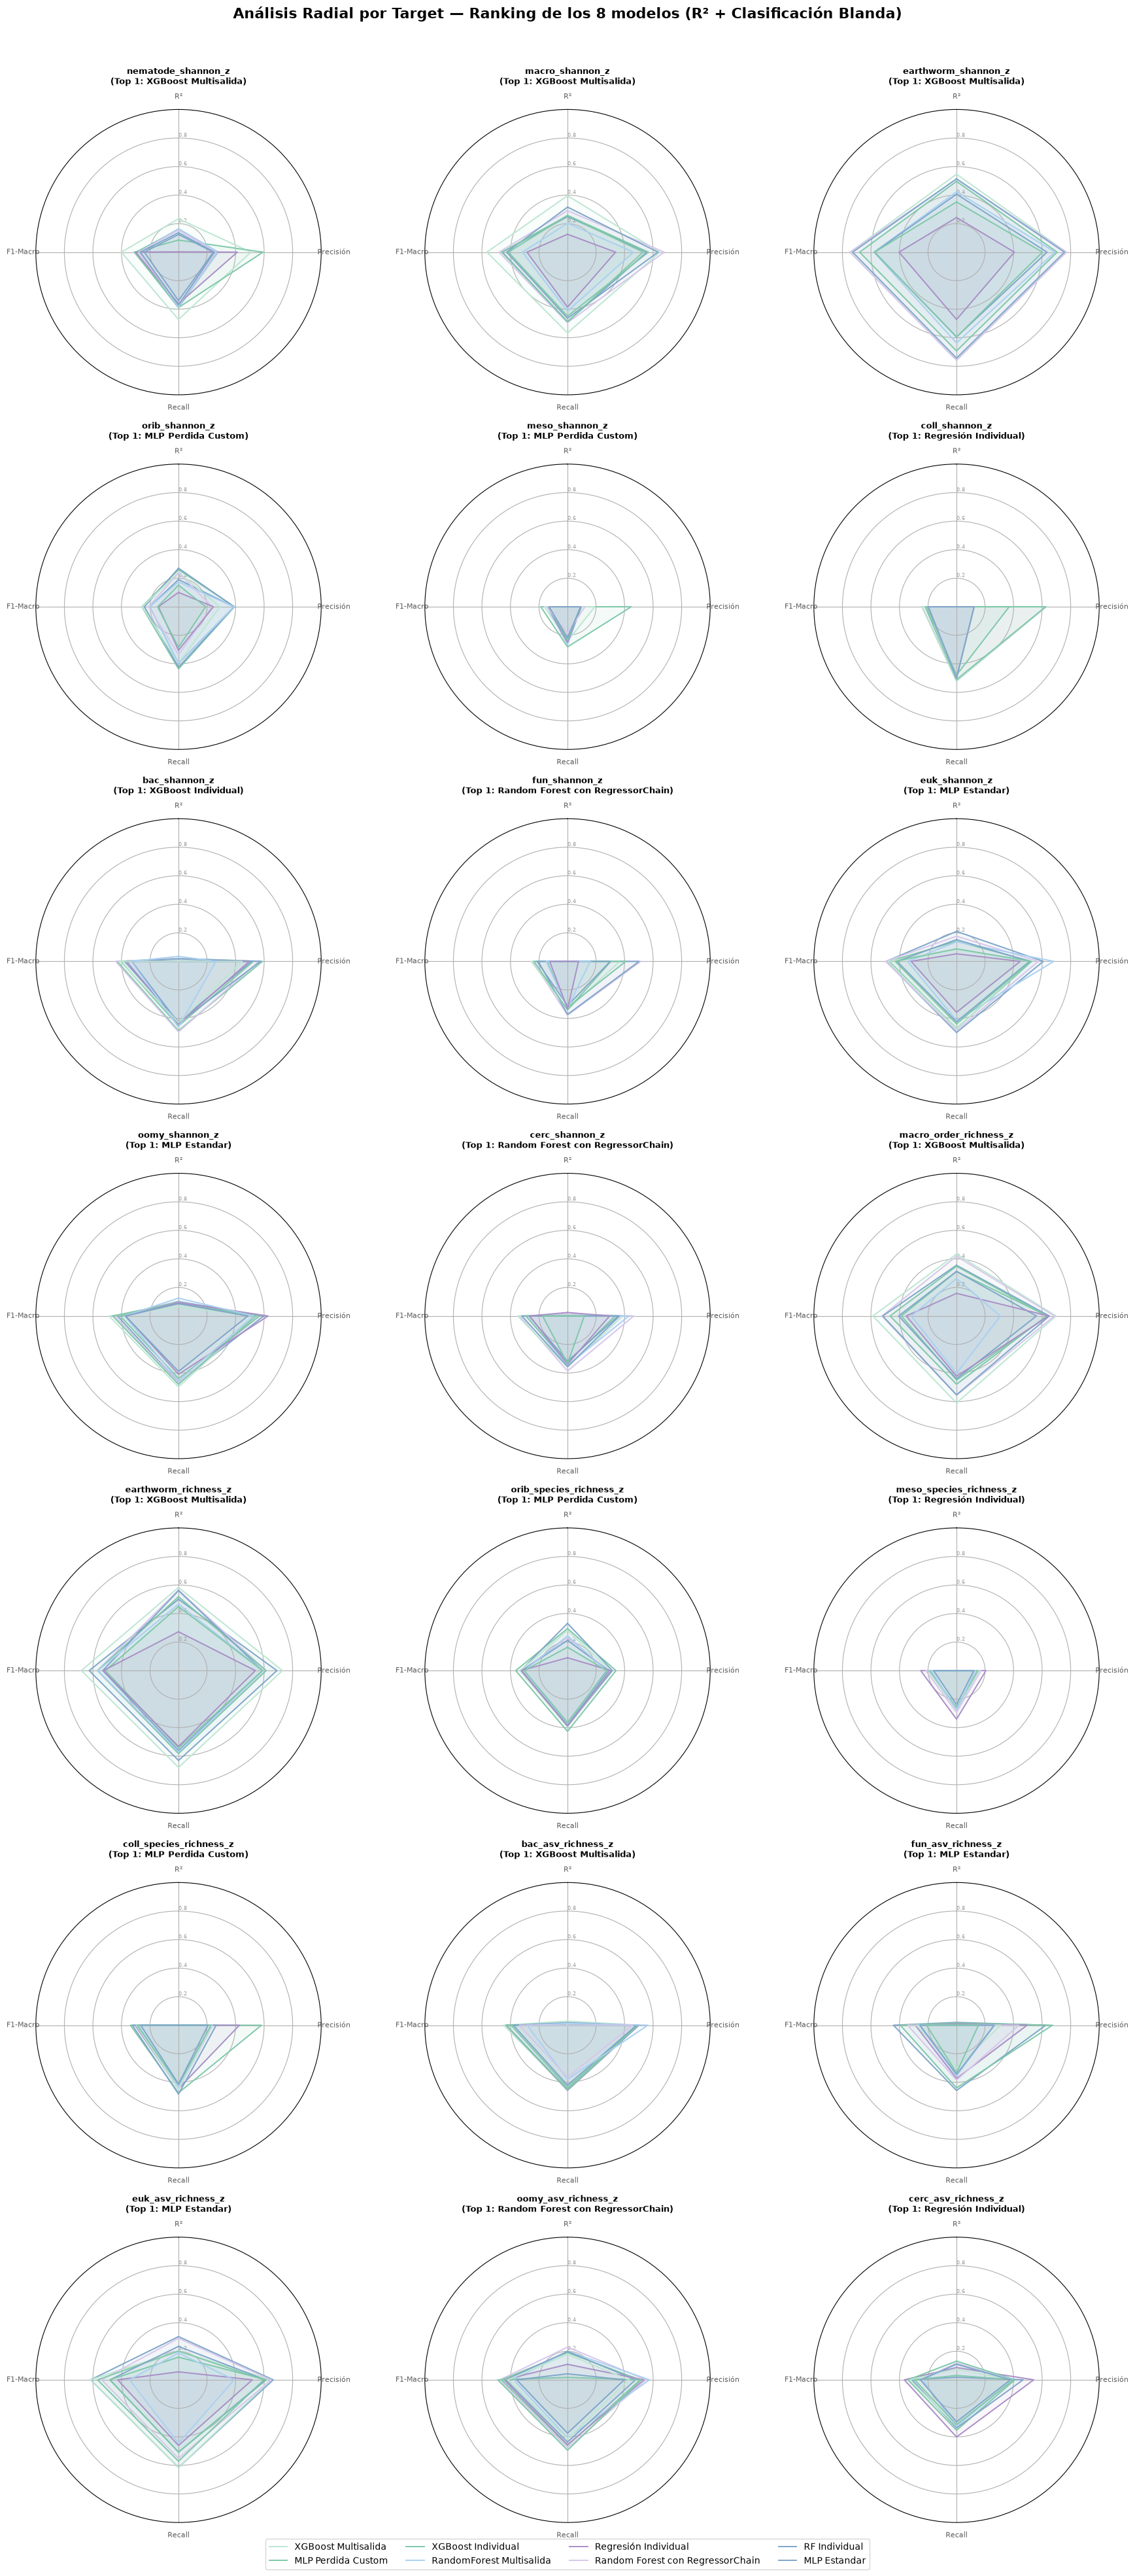

In [10]:
# Paso 7: Radar por target - Top 8 modelos (ranking completo de los 8 modelos, por target)
os.makedirs('output/regresion/graphs/por_target', exist_ok=True)

n_targets = len(TARGETS)
n_cols_t  = 3
n_rows_t  = int(np.ceil(n_targets / n_cols_t))

fig_t, axes_t = plt.subplots(n_rows_t, n_cols_t, figsize=(6 * n_cols_t, 5.5 * n_rows_t),
                              subplot_kw=dict(projection='polar'))
axes_t = axes_t.flatten()

print("  Top 8 modelos por target (R2 + Clasificación)  ")

for k, target in enumerate(TARGETS):
    ax = axes_t[k]
    df_t = (df_radar_target[df_radar_target['Target'] == target]
            .sort_values('Score_Compuesto', ascending=False)
            .reset_index(drop=True))

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    plt.sca(ax)
    plt.xticks(angulos[:-1], categorias, color=PALETTE['gray_dark'], size=8)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color=PALETTE['gray'], size=6)
    plt.ylim(0, 1)

    for i, fila in df_t.iterrows():
        valores_t = [max(0, fila['R2']), fila['Precision'], fila['Recall'], fila['F1_Macro']]
        valores_t += valores_t[:1]
        color_m = color_por_modelo[fila['Modelo']]
        ax.plot(angulos, valores_t, linewidth=1.4, linestyle='solid',
                color=color_m, label=fila['Modelo'] if k == 0 else None)
        ax.fill(angulos, valores_t, color=color_m, alpha=0.08)

    ax.set_title(f"{target}\n(Top 1: {df_t.iloc[0]['Modelo']})", fontsize=9, fontweight='bold', pad=10)

    # Dirgama de araña individual por target 
    fig_ind_t, ax_ind_t = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='polar'))
    ax_ind_t.set_theta_offset(np.pi / 2)
    ax_ind_t.set_theta_direction(-1)
    plt.sca(ax_ind_t)
    plt.xticks(angulos[:-1], categorias, color=PALETTE['gray_dark'], size=10)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color=PALETTE['gray'], size=8)
    plt.ylim(0, 1)
    for i, fila in df_t.iterrows():
        color_m = color_por_modelo[fila['Modelo']]
        valores_t = [max(0, fila['R2']), fila['Precision'], fila['Recall'], fila['F1_Macro']]
        valores_t += valores_t[:1]
        ax_ind_t.plot(angulos, valores_t, linewidth=2, linestyle='solid', color=color_m, label=fila['Modelo'])
        ax_ind_t.fill(angulos, valores_t, color=color_m, alpha=0.08)
    ax_ind_t.set_title(f"Análisis Radial por Target: {target}", fontsize=12, fontweight='bold', pad=15)
    ax_ind_t.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=7)
    fig_ind_t.tight_layout()
    fig_ind_t.savefig(f"output/regresion/graphs/por_target/radar_{target}.png", dpi=200, bbox_inches='tight')
    plt.close(fig_ind_t)

    # Ranking Top 8 impreso para este target
    print(f"\n{target}:")
    for i, fila in df_t.iterrows():
        print(f"  Top {i+1}: {fila['Modelo']:<35} | Compuesto: {fila['Score_Compuesto']:.4f} | "
              f"R2: {fila['R2']:>7.4f} | P: {fila['Precision']:.4f} | R: {fila['Recall']:.4f} | "
              f"F1: {fila['F1_Macro']:.4f}")

for j in range(n_targets, len(axes_t)):
    axes_t[j].set_visible(False)

handles, labels = axes_t[0].get_legend_handles_labels()
fig_t.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.01), fontsize=10)
fig_t.suptitle("Análisis Radial por Target — Ranking de los 8 modelos (R² + Clasificación Blanda)",
               fontsize=16, fontweight='bold', y=1.01)
fig_t.tight_layout()
fig_t.savefig('output/regresion/graphs/mosaico_radar_por_target.png', dpi=250, bbox_inches='tight')
plt.show()


  Mejor model para cada target  
                 Target                           Modelo  Score_Compuesto        R2  Precision   Recall  F1_Macro
     nematode_shannon_z              XGBoost Multisalida         0.403617  0.233928   0.507673 0.471673  0.401195
        macro_shannon_z              XGBoost Multisalida         0.543802  0.395771   0.647222 0.566343  0.565873
    earthworm_shannon_z              XGBoost Multisalida         0.705234  0.546583   0.770330 0.757842  0.746183
         orib_shannon_z               MLP Perdida Custom         0.336069  0.260199   0.391813 0.435897  0.256365
         meso_shannon_z               MLP Perdida Custom         0.228966 -0.439051   0.446809 0.281481  0.187573
         coll_shannon_z              XGBoost Multisalida         0.347285 -0.429405   0.626984 0.520408  0.241747
          bac_shannon_z               XGBoost Individual         0.381366  0.020859   0.588349 0.485632  0.430624
          fun_shannon_z Random Forest con RegressorChai

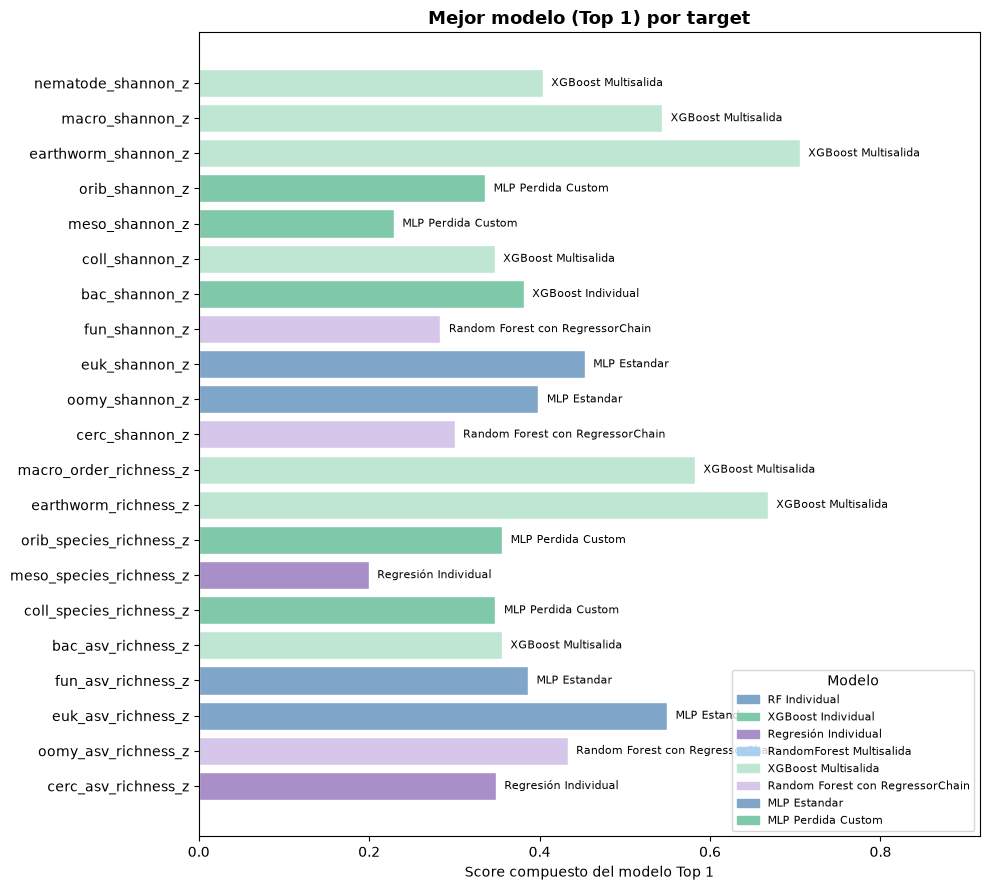


Resumen guardado en output/regresion/top1_modelo_por_target.csv


In [11]:
# Paso 8: Resumen - Top 1 modelo por cada target
df_top1_target = (
    df_radar_target.sort_values('Score_Compuesto', ascending=False)
    .groupby('Target', sort=False).first()
    .reindex(TARGETS)
    .reset_index()[['Target', 'Modelo', 'Score_Compuesto', 'R2', 'Precision', 'Recall', 'F1_Macro']]
)

print("  Mejor model para cada target  ")
print(df_top1_target.to_string(index=False))

conteo_top1 = df_top1_target['Modelo'].value_counts()
print("\nNumero de targets en los que cada modelo es el Top 1:")
for modelo, count in conteo_top1.items():
    print(f"  {modelo:<35}: {count} / {len(TARGETS)} targets")

# Grafico resumen: modelo Top 1 por target, coloreado por modelo (mismo color que en los radares)
fig, ax = plt.subplots(figsize=(10, 9))
colores_top1 = [color_por_modelo[m] for m in df_top1_target['Modelo']]
bars = ax.barh(df_top1_target['Target'], df_top1_target['Score_Compuesto'],
               color=colores_top1, edgecolor='white')
for bar, modelo in zip(bars, df_top1_target['Modelo']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, modelo, va='center', fontsize=8)
ax.set_xlabel('Score compuesto del modelo Top 1')
ax.set_title('Mejor modelo (Top 1) por target', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(df_top1_target['Score_Compuesto']) * 1.3)
ax.invert_yaxis()

handles = [plt.Rectangle((0, 0), 1, 1, color=color_por_modelo[m]) for m in modelos_lista]
ax.legend(handles, modelos_lista, loc='lower right', fontsize=8, title='Modelo')

plt.tight_layout()
os.makedirs('output/regresion/graphs', exist_ok=True)
fig.savefig('output/regresion/graphs/resumen_top1_por_target.png', dpi=250, bbox_inches='tight')
plt.show()

df_top1_target.to_csv('output/regresion/top1_modelo_por_target.csv', index=False)
print("\nResumen guardado en output/regresion/top1_modelo_por_target.csv")